In [132]:
# Load the carsales data
import pandas as pd
carsales = pd.read_csv('carsales.csv')

# Data Cleansing

In [133]:
# Display the first 5 rows
carsales.head()

,Month,Monthly car sales in Quebec 1960-1968
0,1960-01,6550.0
1,1960-02,8728.0
2,1960-03,12026.0
3,1960-04,14395.0
4,1960-05,14587.0


In [134]:
# Change column names to 'month' and 'sales'
carsales.columns = ['month', 'sales']

In [135]:
# Display the last 3 rows
carsales.tail(3)

,month,sales
106,1968-11,17180.0
107,1968-12,14577.0
108,Monthly car sales in Quebec 1960-1968,NaN


##### Observation: The last row is an invalid record used as a descriptor

#### Cleaning Erroneous Data

In [136]:
# Drop the last row that was a header row for the csv file by creating a copy without the last row
carsales = carsales.loc[0:107,:].copy()

In [137]:
# Display the last 3 rows
carsales.tail(3)

,month,sales
105,1968-10,21342.0
106,1968-11,17180.0
107,1968-12,14577.0


In [138]:
# Display the last 3 rows to verify the row was removed
carsales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   month   108 non-null    object 
 1   sales   108 non-null    float64
dtypes: float64(1), object(1)
memory usage: 1.8+ KB


In [139]:
# Add a column called 'period' with numbers 0 to 107 that corresponds to the index value
carsales['period']=list(range(108))

In [140]:
# Display the first 3 rows
carsales.head(3)

,month,sales,period
0,1960-01,6550.0,0
1,1960-02,8728.0,1
2,1960-03,12026.0,2


#### Plotting Data to Find Trends

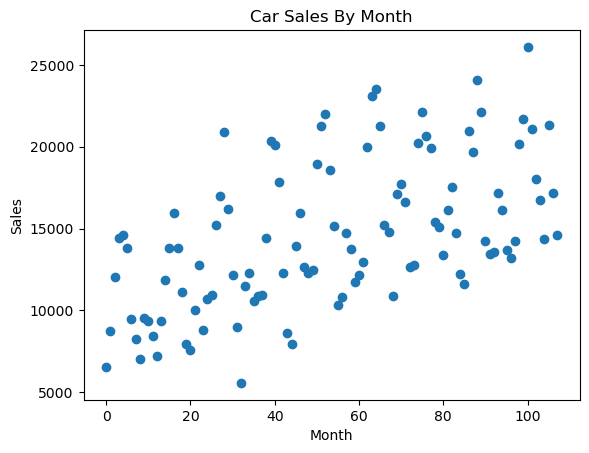

In [141]:
# Create scatterplot of car sales by month
import matplotlib.pyplot as plt
plt.scatter(data=carsales, y='sales', x='period')
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Car Sales By Month")
plt.show()

##### Observations: Car sales appear to be increasing over time although it is noisy with large variations

## Performing Linear Regression

In [142]:
# Create the X and y arrays for modeling
X = carsales['period'].values.reshape(-1,1) # must convert the one dimensional array into 2 dimensions
y = carsales['sales'] # does not have to be reshaped

In [143]:
# Create linear regression model
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X,y)

LinearRegression()

In [144]:
# Return the period coefficient and y intercept values of the model
print(regressor.coef_)
print(regressor.intercept_)

[81.20250174]
10250.777268093781


#### Examine the linear model against the plotted data

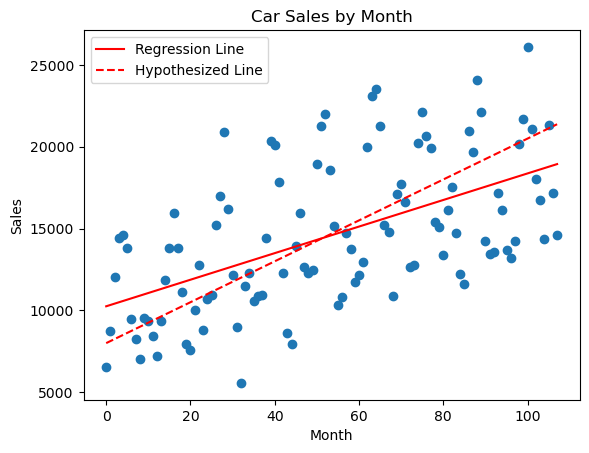

In [145]:
# Plot the period and sales data
plt.scatter(carsales['period'], carsales['sales'])

# Plot the regression line determined in the LinearRegression model above
plt.plot(carsales['period'], [81.2 * i + 10250.8 for i in carsales['period']], 'r-', label='Regression Line')

# PLot a hypothesized line determined by the business. This is a guess of what may be happening
plt.plot(carsales['period'], [125* i+8000 for i in carsales['period']], 'r--', label='Hypothesized Line')
plt.legend(loc="upper left")
plt.title("Car Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

## Calculating Residual Error Measurements

In [146]:
# Manually calculate the residual errors for the regression line and hypothesized line
saleslist = carsales['sales'].tolist()
regressionline = [81.2* i + 10250.8 for i in carsales['period']]
hypothesizedline = [125 * i + 8000 for i in carsales['period']]
error1 = [[x-y] for x,y in zip(regressionline, saleslist)]
error2 = [[x-y] for x,y in zip(hypothesizedline, saleslist)]

In [147]:
#print(error1)
#print(error2)

#### Mean Absolute Error (MAE)

In [148]:
import numpy as np

In [149]:
# Manually calculate the MAE for the regression line and hypothesized line
error1abs = [np.abs(value) for value in error1]
error2abs = [np.abs(value) for value in error2]
print(np.mean(error1abs))
print(np.mean(error2abs))

3154.3592592592595
3239.777777777778


In [150]:
# Calculate MAE for the linear regressor model using sklearn
from sklearn.metrics import mean_absolute_error
y_pred = regressor.predict(X)
mean_absolute_error(y, y_pred)

3154.377291328597

##### Observations:
 - MAE for the regression line is lower than the hypothesized line as expected
 - The lower the MAE, the better
 - The value is based on the non-standardized sales value
 - Use sklearn metrics

#### Root Mean Squared Error (RMSE)

In [151]:
# Manually calculate the RMSE for the regrssion line and hypothesized line
error1squared = [np.power(value,2) for value in error1]
error2squared = [np.power(value,2)for value in error2]
print(np.sqrt(np.mean(error1squared)))
print(np.sqrt(np.mean(error2squared)))

3725.491219512759
3968.900519455399


In [152]:
# Calculate the RMSE for the linear regressor model using sklearn
from sklearn.metrics import root_mean_squared_error
root_mean_squared_error(y, y_pred)

3725.4912170394464

##### Observations:
 - The RMSE for the regression line is lower than the hypothesized line as expected
 - The lwoer the RMSE, the better,
 - The value is based on the non-standardized sales value
 - Use sklearn metrics

#### Create functions for MAE and RMSE

In [153]:
# Manually create the MAE and RMSE functions instead of using sklearn
def get_mae(line, actual):
    error=[[(x-y) for x,y in zip(line,actual)]]
    errorabs=[np.abs(value) for value in error]
    mae=np.mean(errorabs)
    return mae

def get_rmse(line, actual):
    error = [[x-y] for x,y in zip(line,actual)]
    errorsquared=[np.power(value,2) for value in error]
    rmse= np.sqrt(np.mean(errorsquared))
    return rmse

In [154]:
# Calculate MAE for regression line and hypothesized line
print(f"MAE for regression line: {round(get_mae(regressionline, saleslist),2)}")
print(f"MAE for the hypothesized line: {round(get_mae(hypothesizedline, saleslist),2)}")

MAE for regression line: 3154.36
MAE for the hypothesized line: 3239.78


In [155]:
# Calculate the RMSE for regression line and hypothesized line
print(f"RMSE for regression line: {round(get_rmse(regressionline, saleslist),2)}")
print(f"RMSE for hypothesized line: {round(get_rmse(hypothesizedline, saleslist),2)}")

RMSE for regression line: 3725.49
RMSE for hypothesized line: 3968.9


##### Observations:
 - While manually creating functions for MAE and RMSE is possible, using Scikit makes more sense

## Using Regression to Forecast Future Trends

In [156]:
# Extend the sales period to 115 from 107
x_extended = np.append(carsales['period'],np.arange(108,116))

In [157]:
# Predict the new sales based on the extended sales period
x_extended = x_extended.reshape(-1,1) # must convert the one dimensional array into 2 dimensions
extended_prediction = regressor.predict(x_extended)

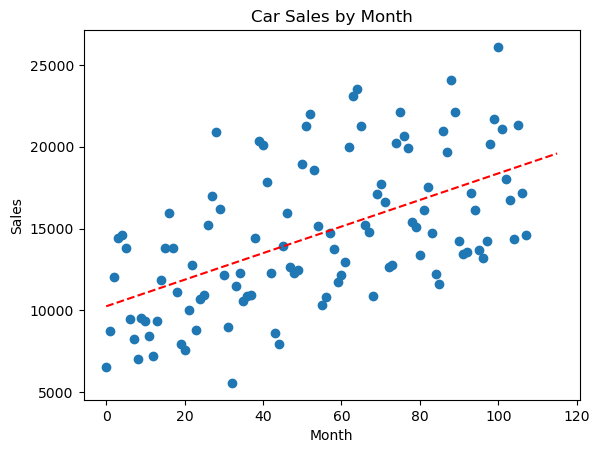

In [158]:
# Plot the new regression line against the car sales data using a scatterplot 
plt.scatter(carsales['period'],carsales['sales'])
plt.plot(x_extended,extended_prediction,'r--')
plt.title("Car Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

##### Observations:
 - The new forecasted data points appear similar to the past actual data

## Multivariate Linear Regression to Predict Sales

In [159]:
# Make copy of carsales for manual polynomials
carsales_man_poly = carsales.copy()

# Create 2 new fields for the carsales data - a squared and cubic values of the period value 
carsales_man_poly["quadratic"]=carsales_man_poly["period"].apply(lambda x: x**2)
carsales_man_poly['cubic']=carsales_man_poly['period'].apply(lambda x:x**3)

In [163]:
# Display first 5 rows of the manually created polynomials
carsales_man_poly.head()

,month,sales,period,quadratic,cubic
0,1960-01,6550.0,0,0,0
1,1960-02,8728.0,1,1,1
2,1960-03,12026.0,2,4,8
3,1960-04,14395.0,3,9,27
4,1960-05,14587.0,4,16,64


In [161]:
# Use PolynomialFeatures to create the polynomials

from sklearn.preprocessing import PolynomialFeatures

features = ['period','quadratic','cubic']
poly = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly.fit_transform(carsales[['period']])
X_poly_df = pd.DataFrame(X_poly, columns = features)
X_poly_df.drop(columns='period', inplace=True)
X_poly_df.head()

,quadratic,cubic
0,0.0,0.0
1,1.0,1.0
2,4.0,8.0
3,9.0,27.0
4,16.0,64.0


In [164]:
# Create new dataset carsales_sklearn_poly by concatenating carsales and the polynomials
carsales_sklearn_poly = pd.concat([carsales, X_poly_df], axis=1)
carsales_sklearn_poly.head()

,month,sales,period,quadratic,cubic
0,1960-01,6550.0,0,0.0,0.0
1,1960-02,8728.0,1,1.0,1.0
2,1960-03,12026.0,2,4.0,8.0
3,1960-04,14395.0,3,9.0,27.0
4,1960-05,14587.0,4,16.0,64.0


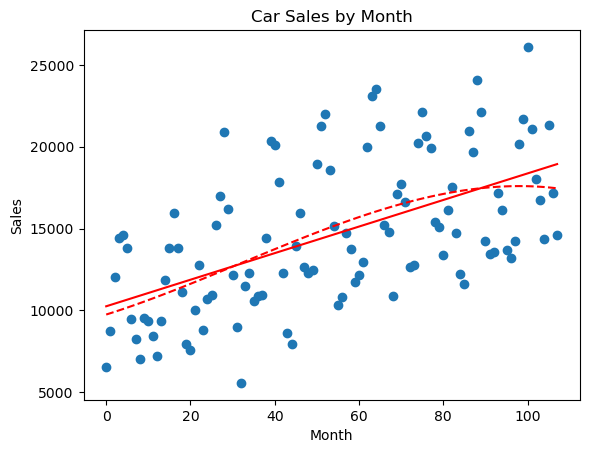

In [165]:
# Create the X and y inputs and targets for the linear regression model
x3=carsales_man_poly.loc[:,['period','quadratic','cubic']] # this does not need to be reshaped as there is more than 1 column
y=carsales_man_poly['sales'] # this does not need to be reshaped

regressor_cubic = LinearRegression()
regressor_cubic.fit(x3,y)
plt.scatter(carsales_man_poly['period'],carsales_man_poly['sales'])
plt.plot(X, regressor.predict(X), 'r-')
plt.plot(X, regressor_cubic.predict(x3), 'r--')
plt.title("Car Sales by Month")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

In [166]:
# Print the 3 coefficients and the y intercept values
print(regressor_cubic.coef_)
print(regressor_cubic.intercept_)

[ 8.13410634e+01  7.90279561e-01 -8.19451188e-03]
9746.412760550356


##### Observations:
 - The polynomial regression line predicts future decreases in sales while the linear regression line predicts increases

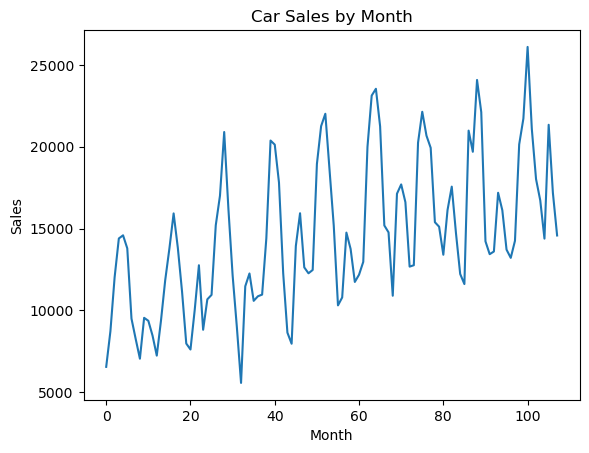

In [98]:
# Plot the car sales by period as a line plot instead of a scatterplot
import matplotlib.pyplot as plt
plt.plot(carsales['period'],carsales['sales'])
plt.title('Car Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

##### Observations:
 - The line plot above goes up and down like a trigonometric sine or cosine curve

## Use sine and cosine of the period 

In [101]:
import math

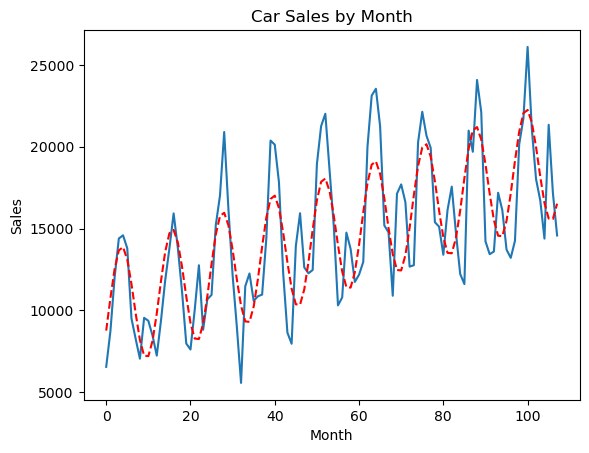

In [170]:
# Create 2 new fields for the sine and cosine of the field 'period'
carsales_man_poly['sin_period'] = carsales_man_poly['period'].apply(lambda x: math.sin(x*2*math.pi/12))
carsales_man_poly['cos_period'] = carsales_man_poly['period'].apply(lambda x: math.cos(x*2*math.pi/12))

# Add the sine and cosine fields to the X variables
x_trig = carsales_man_poly.loc[:,['period','sin_period','cos_period']]
y = carsales_man_poly['sales']

regressor_trig = LinearRegression()
regressor_trig.fit(x_trig, y)

# Plot the predicted y values against the actual y values
plt.plot(carsales_man_poly['period'], carsales_man_poly['sales'])
plt.plot(X, regressor_trig.predict(x_trig),'r--')
plt.title('Car Sales by Month')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.show()

In [33]:
# Calculate the RMSE value for the model
trig_line = regressor_trig.predict(x_trig)[:,0]
print(get_rmse(trig_line,saleslist))

2680.5520744410464


In [168]:
carsales_man_poly.head()

,month,sales,period,quadratic,cubic,sin_period,cos_period
0,1960-01,6550.0,0,0,0,0.000000,1.000000e+00
1,1960-02,8728.0,1,1,1,0.500000,8.660254e-01
2,1960-03,12026.0,2,4,8,0.866025,5.000000e-01
3,1960-04,14395.0,3,9,27,1.000000,6.123234e-17
4,1960-05,14587.0,4,16,64,0.866025,-5.000000e-01
